In [1]:
from typing import Iterator
import itertools

In [2]:
def get_alpha_excitations(
    num_spatial_orbitals: int,
    num_alpha: int,
    *,
    generalized: bool = False,
):
    """Generates all possible single alpha-electron excitations.

    This method assumes block-ordered spin-orbitals.

    Args:
        num_alpha: the number of alpha electrons.
        num_spatial_orbitals: the number of spatial-orbitals.
        generalized: boolean flag whether or not to use generalized excitations, which ignore the
            occupation of the spin orbitals. As such, the set of generalized excitations is only
            determined from the number of spin orbitals and independent from the number of alpha
            electrons.

    Returns:
        The list of excitations encoded as tuples. Each tuple is a pair. The first entry contains
        the occupied spin orbital index and the second entry the unoccupied one.
    """
    if generalized:
        return list(itertools.combinations(range(num_spatial_orbitals), 2))

    alpha_occ = range(num_alpha)
    alpha_unocc = range(num_alpha, num_spatial_orbitals)

    return list(itertools.product(alpha_occ, alpha_unocc))

In [3]:
def get_beta_excitations(
    num_spatial_orbitals: int,
    num_beta: int,
    *,
    generalized: bool = False,
):
    """Generates all possible single beta-electron excitations.

    This method assumes block-ordered spin-orbitals.

    Args:
        num_beta: the number of beta electrons.
        num_spatial_orbitals: the total number of spatial-orbitals.
        generalized: boolean flag whether or not to use generalized excitations, which ignore the
            occupation of the spin orbitals. As such, the set of generalized excitations is only
            determined from the number of spin orbitals and independent from the number of beta
            electrons.

    Returns:
        The list of excitations encoded as tuples. Each tuple is a pair. The first entry contains
        the occupied spin orbital index and the second entry the unoccupied one.
    """
    num_spin_orbitals = 2 * num_spatial_orbitals
    if generalized:
        return list(itertools.combinations(range(num_spatial_orbitals, num_spin_orbitals), 2))

    beta_index_offset = num_spatial_orbitals
    beta_occ = range(beta_index_offset, beta_index_offset + num_beta)
    beta_unocc = range(beta_index_offset + num_beta, num_spin_orbitals)

    return list(itertools.product(beta_occ, beta_unocc))

In [4]:
def generate_fermionic_excitations(
    num_excitations,
    num_spatial_orbitals,
    num_particles,
    *,
    alpha_spin = True,
    beta_spin = True,
    max_spin_excitation = None,
    generalized = False,
    preserve_spin = True,
):
    num_spin_orbitals = 2 * num_spatial_orbitals
    alpha_excitations = []
    beta_excitations = []

    if preserve_spin:
        if alpha_spin:
            alpha_excitations = get_alpha_excitations(
                num_spatial_orbitals, num_particles[0], generalized=generalized
            )
            #logger.debug("Generated list of single alpha excitations: %s", alpha_excitations)

        if beta_spin:
            beta_excitations = get_beta_excitations(
                num_spatial_orbitals, num_particles[1], generalized=generalized
            )
            #logger.debug("Generated list of single beta excitations: %s", beta_excitations)

    print('alpha_excitations', alpha_excitations)
    print('beta_excitations', beta_excitations)

    pool = itertools.combinations(
        alpha_excitations + beta_excitations, num_excitations
    )

    print(alpha_excitations + beta_excitations)

    excitations = []
    visited_excitations = set()

    for exc in pool:
        # validate an excitation by asserting that all indices are unique:
        #   1. get the frozen set of indices in the excitation
        exc_set = frozenset(itertools.chain.from_iterable(exc))
        #   2. all indices must be unique (size of set equals 2 * num_excitations)
        #   3. and we also don't want to include permuted variants of identical excitations
        if len(exc_set) == num_excitations * 2 and exc_set not in visited_excitations:
            visited_excitations.add(exc_set)
            occ: tuple[int, ...]
            unocc: tuple[int, ...]
            occ, unocc = zip(*exc)
            exc_tuple = (occ, unocc)
            excitations.append(exc_tuple)
    return excitations

In [8]:
excitations_list1 = generate_fermionic_excitations(num_excitations=1, num_spatial_orbitals=2, num_particles=(1,1), generalized=True)

alpha_excitations [(0, 1)]
beta_excitations [(2, 3)]
[(0, 1), (2, 3)]


In [9]:
excitations_list1

[((0,), (1,)), ((2,), (3,))]

In [10]:
excitations_list2 = generate_fermionic_excitations(num_excitations=2, num_spatial_orbitals=2, num_particles=(1,1), generalized=True)

alpha_excitations [(0, 1)]
beta_excitations [(2, 3)]
[(0, 1), (2, 3)]


In [11]:
excitations_list2

[((0, 2), (1, 3))]

In [ ]:
from itertools import combinations
 
letters ="GeEKS"
 
# size of combination is set to 3
a = combinations(letters, 1) 
y = [' '.join(i) for i in a]
 
print(y)

['G', 'e', 'E', 'K', 'S']


In [1]:
from qiskit_nature.second_q.circuit.library.ansatzes.utils.fermionic_excitation_generator import generate_fermionic_excitations

In [31]:
singles_excitations_list = generate_fermionic_excitations(num_excitations=2, num_spatial_orbitals=4, num_particles=(2,2), generalized=True)

In [32]:
singles_excitations_list

[((0, 2), (1, 3)),
 ((0, 4), (1, 5)),
 ((0, 4), (1, 6)),
 ((0, 4), (1, 7)),
 ((0, 5), (1, 6)),
 ((0, 5), (1, 7)),
 ((0, 6), (1, 7)),
 ((0, 4), (2, 5)),
 ((0, 4), (2, 6)),
 ((0, 4), (2, 7)),
 ((0, 5), (2, 6)),
 ((0, 5), (2, 7)),
 ((0, 6), (2, 7)),
 ((0, 4), (3, 5)),
 ((0, 4), (3, 6)),
 ((0, 4), (3, 7)),
 ((0, 5), (3, 6)),
 ((0, 5), (3, 7)),
 ((0, 6), (3, 7)),
 ((1, 4), (2, 5)),
 ((1, 4), (2, 6)),
 ((1, 4), (2, 7)),
 ((1, 5), (2, 6)),
 ((1, 5), (2, 7)),
 ((1, 6), (2, 7)),
 ((1, 4), (3, 5)),
 ((1, 4), (3, 6)),
 ((1, 4), (3, 7)),
 ((1, 5), (3, 6)),
 ((1, 5), (3, 7)),
 ((1, 6), (3, 7)),
 ((2, 4), (3, 5)),
 ((2, 4), (3, 6)),
 ((2, 4), (3, 7)),
 ((2, 5), (3, 6)),
 ((2, 5), (3, 7)),
 ((2, 6), (3, 7)),
 ((4, 6), (5, 7))]

In [33]:
as_spin_orb_list = [[1,2,5,6], [0,3,4,7]]

new_singles_excitations_list = []
for i in range(len(singles_excitations_list)):
    n = tuple(singles_excitations_list[i][0] + singles_excitations_list[i][1])
    n_list = list(n)
    sorted_n_list = sorted(n_list)

    subset_list = []
    for as_spin_orb in as_spin_orb_list:
        print(as_spin_orb)
        is_subset = set(sorted_n_list).issubset(as_spin_orb)
        print(sorted_n_list)
        subset_list.append(is_subset)

    print(subset_list)
    
    if not any(subset_list)==True:
        new_singles_excitations_list.append(singles_excitations_list[i])


[1, 2, 5, 6]
[0, 1, 2, 3]
[0, 3, 4, 7]
[0, 1, 2, 3]
[False, False]
[1, 2, 5, 6]
[0, 1, 4, 5]
[0, 3, 4, 7]
[0, 1, 4, 5]
[False, False]
[1, 2, 5, 6]
[0, 1, 4, 6]
[0, 3, 4, 7]
[0, 1, 4, 6]
[False, False]
[1, 2, 5, 6]
[0, 1, 4, 7]
[0, 3, 4, 7]
[0, 1, 4, 7]
[False, False]
[1, 2, 5, 6]
[0, 1, 5, 6]
[0, 3, 4, 7]
[0, 1, 5, 6]
[False, False]
[1, 2, 5, 6]
[0, 1, 5, 7]
[0, 3, 4, 7]
[0, 1, 5, 7]
[False, False]
[1, 2, 5, 6]
[0, 1, 6, 7]
[0, 3, 4, 7]
[0, 1, 6, 7]
[False, False]
[1, 2, 5, 6]
[0, 2, 4, 5]
[0, 3, 4, 7]
[0, 2, 4, 5]
[False, False]
[1, 2, 5, 6]
[0, 2, 4, 6]
[0, 3, 4, 7]
[0, 2, 4, 6]
[False, False]
[1, 2, 5, 6]
[0, 2, 4, 7]
[0, 3, 4, 7]
[0, 2, 4, 7]
[False, False]
[1, 2, 5, 6]
[0, 2, 5, 6]
[0, 3, 4, 7]
[0, 2, 5, 6]
[False, False]
[1, 2, 5, 6]
[0, 2, 5, 7]
[0, 3, 4, 7]
[0, 2, 5, 7]
[False, False]
[1, 2, 5, 6]
[0, 2, 6, 7]
[0, 3, 4, 7]
[0, 2, 6, 7]
[False, False]
[1, 2, 5, 6]
[0, 3, 4, 5]
[0, 3, 4, 7]
[0, 3, 4, 5]
[False, False]
[1, 2, 5, 6]
[0, 3, 4, 6]
[0, 3, 4, 7]
[0, 3, 4, 6]
[False, Fa

In [34]:
new_singles_excitations_list

[((0, 2), (1, 3)),
 ((0, 4), (1, 5)),
 ((0, 4), (1, 6)),
 ((0, 4), (1, 7)),
 ((0, 5), (1, 6)),
 ((0, 5), (1, 7)),
 ((0, 6), (1, 7)),
 ((0, 4), (2, 5)),
 ((0, 4), (2, 6)),
 ((0, 4), (2, 7)),
 ((0, 5), (2, 6)),
 ((0, 5), (2, 7)),
 ((0, 6), (2, 7)),
 ((0, 4), (3, 5)),
 ((0, 4), (3, 6)),
 ((0, 5), (3, 6)),
 ((0, 5), (3, 7)),
 ((0, 6), (3, 7)),
 ((1, 4), (2, 5)),
 ((1, 4), (2, 6)),
 ((1, 4), (2, 7)),
 ((1, 5), (2, 7)),
 ((1, 6), (2, 7)),
 ((1, 4), (3, 5)),
 ((1, 4), (3, 6)),
 ((1, 4), (3, 7)),
 ((1, 5), (3, 6)),
 ((1, 5), (3, 7)),
 ((1, 6), (3, 7)),
 ((2, 4), (3, 5)),
 ((2, 4), (3, 6)),
 ((2, 4), (3, 7)),
 ((2, 5), (3, 6)),
 ((2, 5), (3, 7)),
 ((2, 6), (3, 7)),
 ((4, 6), (5, 7))]

In [25]:
from qiskit.circuit import QuantumCircuit
qc_full = QuantumCircuit(6)

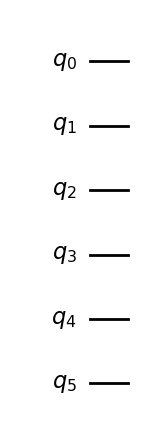

In [27]:
qc_full.draw('mpl')

In [28]:
for i in range(2):
    hea_active_space_state = QuantumCircuit(2)
    hea_active_space_state.x(0)
    hea_active_space_state.cnot(0,1)

    qc_full = qc_full.compose(hea_active_space_state, qubits=[i,i+1])
    qc_full.barrier()
    

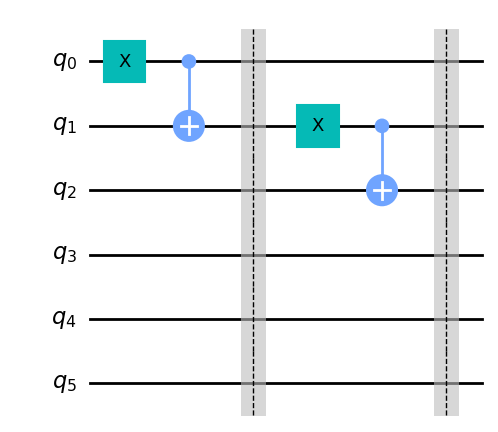

In [29]:
qc_full.draw('mpl')
